# Introduction to RNN Sentiment Analysis with Keras

This session demonstrates two coding approaches for building a **sentiment analysis model using Recurrent Neural Networks (RNNs)** in Keras:

1. **Integer Encoding + Padding**  
   - Text reviews are converted into integer sequences.  
   - Sequences are padded/truncated to a fixed length.  
   - A `SimpleRNN` layer processes the inputs step by step, followed by a dense output layer for classification.  
   - This approach is straightforward but limited in capturing semantic meaning.

2. **Embedding Layer + RNN**  
   - Words are mapped into dense vector representations using an `Embedding` layer.  
   - Embeddings capture semantic relationships between words, improving efficiency and accuracy.  
   - The embedded sequences are fed into RNN units, enabling better context retention and sentiment prediction.  

Together, these examples highlight the evolution from basic integer encoding to more powerful embeddings, showing how RNNs can effectively handle sequential text data for tasks like movie review sentiment classification.


## **Integer Encoding + Padding**

In [1]:
import numpy as np

docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [2]:
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>') #oov_token replaces unseen text with given text (eg. nothing)

In [3]:
tokenizer.fit_on_texts(docs)

In [7]:
tokenizer.word_index

{'<nothing>': 1,
 'india': 2,
 'jeetega': 3,
 'hip': 4,
 'ki': 5,
 'jai': 6,
 'kohli': 7,
 'sachin': 8,
 'dhoni': 9,
 'go': 10,
 'hurray': 11,
 'bhai': 12,
 'bharat': 13,
 'mata': 14,
 'modi': 15,
 'ji': 16,
 'inquilab': 17,
 'zindabad': 18}

In [14]:
print(tokenizer.word_counts,'\n')
print(tokenizer.document_count)

OrderedDict([('go', 1), ('india', 4), ('hip', 2), ('hurray', 1), ('jeetega', 3), ('bhai', 1), ('bharat', 1), ('mata', 1), ('ki', 2), ('jai', 2), ('kohli', 2), ('sachin', 2), ('dhoni', 2), ('modi', 1), ('ji', 1), ('inquilab', 1), ('zindabad', 1)]) 

10


In [15]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [16]:
from keras.utils import pad_sequences
sequences= pad_sequences(sequences, padding='post')

In [17]:
sequences

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]])

In [21]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import *

In [24]:
import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

from keras.datasets import imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data()

17464789/17464789 [==============================] - 12s 1us/step


In [30]:
len(x_train[1])

189

In [26]:
x_train.shape

(25000,)

In [27]:
x_test.shape

(25000,)

In [ ]:
print(np.max(np.max(x_train)))


88325


In [47]:
x_train = pad_sequences(x_train,padding="post", maxlen=100)
x_test = pad_sequences(x_test,padding='post',maxlen=100)

In [48]:
x_train.shape

(25000, 100)

In [49]:
x_train[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [50]:
model = Sequential()

model.add(SimpleRNN(32,input_shape =(100,1), return_sequences=False))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 32)                1088      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,121
Trainable params: 1,121
Non-trainable params: 0
_________________________________________________________________


In [52]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
782/782 [==============================] - 78s 99ms/step - loss: 0.6935 - accuracy: 0.4934 - val_loss: 0.6932 - val_accuracy: 0.5001
Epoch 2/5
782/782 [==============================] - 98s 126ms/step - loss: 0.6934 - accuracy: 0.4995 - val_loss: 0.6932 - val_accuracy: 0.5002
Epoch 3/5
782/782 [==============================] - 93s 119ms/step - loss: 0.6933 - accuracy: 0.4999 - val_loss: 0.6933 - val_accuracy: 0.4999
Epoch 4/5
782/782 [==============================] - 92s 118ms/step - loss: 0.6933 - accuracy: 0.5014 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 5/5
782/782 [==============================] - 97s 124ms/step - loss: 0.6933 - accuracy: 0.4996 - val_loss: 0.6934 - val_accuracy: 0.5003


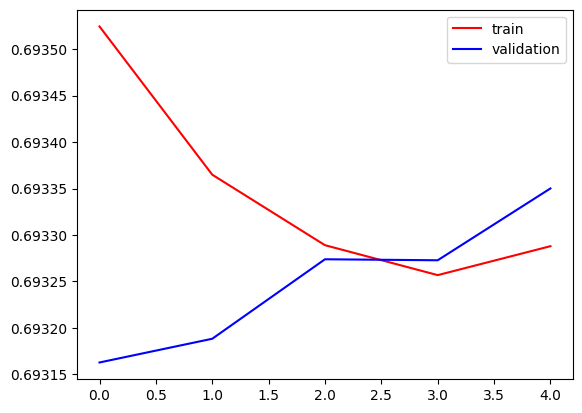

In [54]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

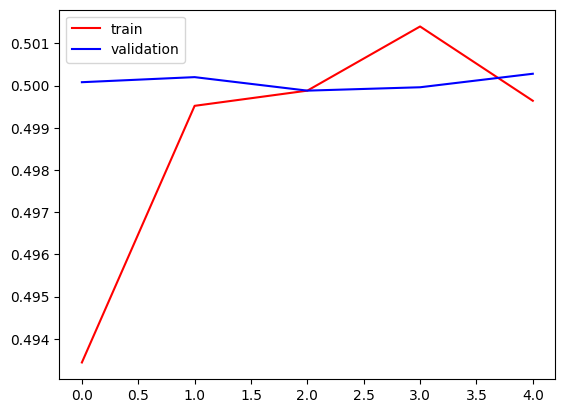

In [55]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

## **Embedding Layer + RNN** 

In [56]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [57]:
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()

In [58]:
tokenizer.fit_on_texts(docs)

In [59]:
len(tokenizer.word_index)

17

In [60]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[9, 1],
 [1, 1],
 [3, 3, 10],
 [2, 11, 2, 1, 2],
 [12, 13, 4, 5],
 [6, 6],
 [7, 7],
 [8, 8],
 [14, 15, 4, 5],
 [16, 17]]

In [61]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')
sequences

array([[ 9,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3, 10,  0,  0],
       [ 2, 11,  2,  1,  2],
       [12, 13,  4,  5,  0],
       [ 6,  6,  0,  0,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [14, 15,  4,  5,  0],
       [16, 17,  0,  0,  0]])

In [62]:
model = Sequential()
model.add(Embedding(17,output_dim=2,input_length=5))

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 5, 2)              34        
                                                                 
Total params: 34
Trainable params: 34
Non-trainable params: 0
_________________________________________________________________


In [63]:
model.compile('adam','accuracy')

In [64]:
pred = model.predict(sequences)
print(pred)

1/1 [==============================] - 0s 101ms/step
[[[ 0.01219716 -0.01682333]
  [-0.00258791 -0.01443787]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]]

 [[-0.00258791 -0.01443787]
  [-0.00258791 -0.01443787]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]]

 [[ 0.04589127 -0.04798649]
  [ 0.04589127 -0.04798649]
  [-0.00050938 -0.04905485]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]]

 [[ 0.02378153 -0.00991651]
  [ 0.02279508  0.04178524]
  [ 0.02378153 -0.00991651]
  [-0.00258791 -0.01443787]
  [ 0.02378153 -0.00991651]]

 [[-0.01731886  0.00079913]
  [ 0.02251912 -0.03738915]
  [-0.02606638  0.04018594]
  [-0.01841278 -0.0025894 ]
  [-0.02475979  0.01677136]]

 [[-0.02158204  0.00675873]
  [-0.02158204  0.00675873]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]
  [-0.02475979  0.01677136]]

 [[ 0.04742074 -0.02774098]
  [ 0.04742074 -0.02774098]
  [-0.02475979  0.01677136]
  [-0.02475

In [65]:
from keras.datasets import imdb
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [66]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

In [67]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [69]:
model = Sequential()
model.add(Embedding(10000, 2,input_length= 50))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 50, 2)             20000     
                                                                 


 simple_rnn_3 (SimpleRNN)    (None, 32)                1120      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 21,153
Trainable params: 21,153
Non-trainable params: 0
_________________________________________________________________


In [70]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5
782/782 [==============================] - 50s 63ms/step - loss: 0.6142 - acc: 0.6269 - val_loss: 0.4698 - val_acc: 0.7767
Epoch 2/5
782/782 [==============================] - 66s 85ms/step - loss: 0.3914 - acc: 0.8266 - val_loss: 0.4239 - val_acc: 0.8096
Epoch 3/5
782/782 [==============================] - 70s 90ms/step - loss: 0.3230 - acc: 0.8671 - val_loss: 0.4419 - val_acc: 0.7974
Epoch 4/5
782/782 [==============================] - 74s 95ms/step - loss: 0.2775 - acc: 0.8900 - val_loss: 0.5133 - val_acc: 0.7985
Epoch 5/5
782/782 [==============================] - 72s 93ms/step - loss: 0.2389 - acc: 0.9090 - val_loss: 0.4804 - val_acc: 0.8005


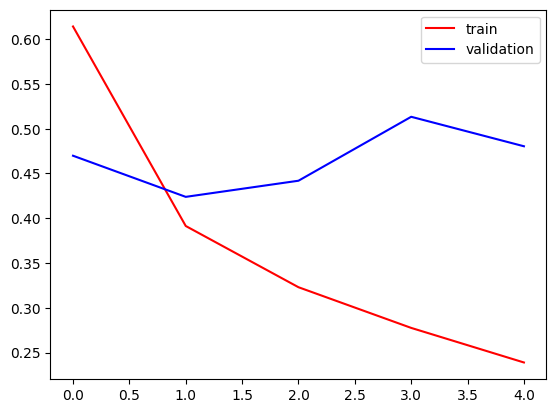

In [71]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

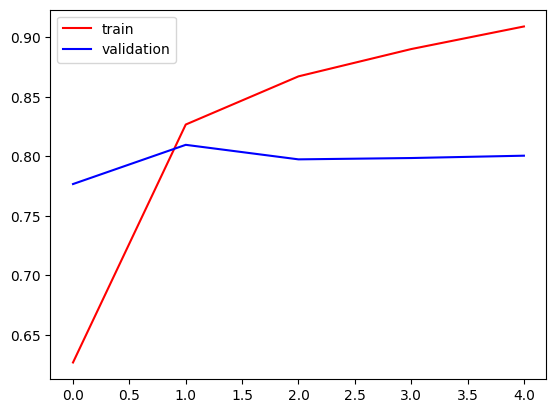

In [73]:
plt.plot(history.history['acc'],color='red',label='train')
plt.plot(history.history['val_acc'],color='blue',label='validation')
plt.legend()
plt.show()